# Constellations et exemples de modulation

In [1]:
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('../signal.mplstyle')

In [25]:
def constellation(ax, a, b, psk_radius=0, title=""):
    """Affiche la constellation sur l'axe ax
    associée à la modulation d'amplitudes définies par a (en phase) et b (en quadrature)"""

    # Initialisation du graphe
    ax.set_facecolor('white')
    amax = np.max(np.abs(a))
    bmax = np.max(np.abs(b))
    xmax = max(amax, bmax) + 1
    xmin = - xmax
    
    # Nombre de symboles
    M = len(a)
        
    # Cercle (si PSK)
    if psk_radius > 0:
        p = mpatches.Circle((0, 0), psk_radius, fill=False, edgecolor="black", linestyle="--", linewidth=.5)
        ax.add_artist(p)
    
    # Axes 0
    ax.plot([xmin-1, xmax+1], [0, 0], 'k', linewidth=.5)
    ax.plot([0, 0], [xmin-1, xmax+1], 'k', linewidth=.5)
    
    # Constellation
    ax.plot(a, b, '.', markersize=15)
    
    # # Symboles associés
    # d = (xmax-xmin)/30
    # for n in range(len(x)):
    #     plt.text(x[n], y[n]+d, n, ha="center") # Nombre en décimal

    # Axes
    ax.set_xlabel("$I$")
    ax.set_ylabel("$Q$")
    ax.set_xticks(np.arange(xmin, xmax+1))
    ax.set_yticks(np.arange(xmin, xmax+1))
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([xmin, xmax])
    ax.set_aspect('equal', 'box')

    # Titre
    if title:
        ax.set_title(title)


def ask(M, d=2):
    """Modulation M-ASK où b = 0 et les points en phase sont espacés de d"""
    amax = (M-1)*d/2
    a = np.arange(-amax, amax+d/2, d)
    b = np.zeros(M)
    return a, b


def psk(M, r=1):
    """Modulation M-PSK sur un cercle de rayon r"""
    t = np.arange(0, 2*np.pi, 2*np.pi/M)
    a = r * np.cos(t)
    b = r * np.sin(t)
    return a, b


def qam(M, d=2):
    """Modulation M-QAM"""
    
    if M == 4:
        a = [+1, -1, -1, +1]
        b = [+1, +1, -1, -1]
    
    if M == 8:
        a, b = np.mgrid[-3*d/2:3*1.1*d/2:d, -d/2:d*1.1/2:d]
    
    # if N == 16:
    #     for x in np.linspace(-3, 3, 4):
    #         for y in np.linspace(-3, 3, 4):
    #             c.append([x, y])
                
    if M == 32:
        a = []
        b = []
        for x in np.linspace(-5, 5, 6):
            for y in np.linspace(-5, 5, 6):
                if np.abs(x) != 5 or np.abs(y) != 5:
                    a.append(x)
                    b.append(y)
    
    return np.array(a).ravel(), np.array(b).ravel()

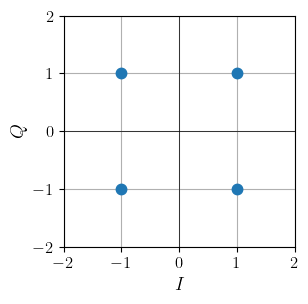

In [29]:
# Constellation 4-QAM
fig, ax = plt.subplots(1, 1, figsize=(3,3))
a, b = qam(M=4, d=2)
constellation(ax, a, b)
plt.savefig("constellation-4qam.svg")
plt.show()

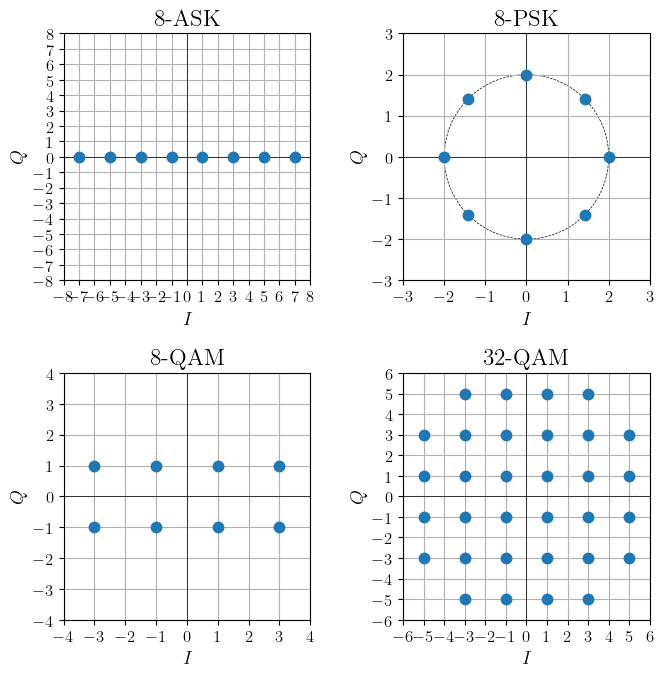

In [30]:
# Nombre de symboles
M = 8

# Figure
fig, axs = plt.subplots(2, 2, figsize=(7,7))

# 8-ASK
a, b = ask(M, d=2)
constellation(axs[0,0], a, b, title="8-ASK")

# 8-PSK
radius = 2
a, b = psk(M, r=radius)
constellation(axs[0,1], a, b, psk_radius=radius, title="8-PSK")

# 8-QAM
a, b = qam(M, d=2)
constellation(axs[1,0], a, b, title="8-QAM")

# 32-QAM
a, b = qam(M=32, d=2)
constellation(axs[1,1], a, b, title="32-QAM")

# Enregistrement et affichage
fig.tight_layout()
plt.savefig("constellation-ask-psk-qam.svg")
plt.show()